In [3]:
import os
import torch
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Torch Version:", torch.__version__)
print("CUDA Availablility:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

Torch Version: 2.5.1+cu121
CUDA Availablility: True
GPU Name: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [4]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from matplotlib import pyplot as plt
from PIL import Image


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5       # map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Resizing the entire dataset to 64x64...
Resizing complete!
Caption: a drawing of a green pokemon with red eyes
Image Object: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x29C0F4F9C10>


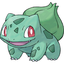

In [ ]:
import torchvision
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
from IPython.display import display

# 0. Load the dataset from Hugging Face
dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")

# 1. Define a function to resize the whole dataset
def resize_images(batch):
    # Resize every image in the current batch to 64x64 using Lanczos resampling
    batch["image"] = [img.resize((64, 64), Image.Resampling.LANCZOS) for img in batch["image"]]
    return batch

print("Resizing the entire dataset to 64x64...")
dataset = dataset.map(resize_images, batched=True)  # .map(batched=True) processes the dataset quickly in batches
print("Resizing complete!")

# 2. Access a single sample (e.g., the first item)
sample = dataset[0]

# 3. Print the text caption and the image details
print(f"Caption: {sample['text']}")
print(f"Image Object: {sample['image']}")  # This will now show size=(64, 64)

# 4. Display the image
display(sample['image'])